# 01 — Kaggle eBay Dataset EDA

**Dataset:** `marketing_sample_for_ebay_com-ebay_com_product__20210101_20210331__30k_data.csv`  
**Period:** Q1 2021 (~30k eBay product listings)

## Problem framing

We are building **Agent 2 — the Pricing Agent** of a multi-agent secondhand-selling system. Its job is:

1. Receive an incoming item (title, description, photos, condition) from Agent 1 (Intake).
2. Fetch comparable sold listings from eBay's Browse/Finding API.
3. Feed those comparables into an XGBoost regression model to predict a fair `suggested_price`.
4. Return a `PricingOutput` schema that includes `suggested_price`, `min_acceptable_price`, and confidence bounds.

This EDA answers the questions that matter for that pipeline:

- **What does price look like?** Distribution, outliers, skew — determines whether we log-transform the target.
- **Which features correlate with price?** Determines which columns are worth engineering.
- **How complete is the data?** Signals which fields we can rely on from the live eBay API.
- **What can we learn from titles?** Informs the NLP feature-extraction step (Agent 5).
- **How important is seller reputation?** Determines whether `seller_rating` belongs in the model.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# consistent style across all plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_PATH = Path('../datasets/marketing_sample_for_ebay_com-ebay_com_product__20210101_20210331__30k_data.csv')

---
## 1. Load & First Look

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False, on_bad_lines='skip')

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Shape: 17,577 rows × 30 columns


,Uniq Id,Crawl Timestamp,Pageurl,Website,Title,Num Of Reviews,Average Rating,Number Of Ratings,Model Num,Sku,...,Specifications,Five Star,Four Star,Three Star,Two Star,One Star,Discontinued,Broken Link,Seller Rating,Seller Num Of Reviews
0,38c0bcb6ce1e5d1750b442dd9446aac9,2021-01-03 08:05:50 +0000,https://www.ebay.com/p/7024512090?iid=16461748...,ebay.com,Samsung Galaxy Note 8 6GB RAM 64GB Dual SIM (U...,NaN,NaN,NaN,SM-N950F,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,NaN,NaN
1,31be03c526b3b65322e73ce617fa0e57,2021-02-17 06:24:23 +0000,https://www.ebay.com/itm/Apple-Airpods-Pro-wit...,ebay.com,Apple Airpods Pro with wireless charging case ...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,False,False,100%,59
2,5f2eacffc44070e54ef3195d4e3889d1,2021-02-17 06:17:19 +0000,https://www.ebay.com/p/238211749?iid=174232921...,ebay.com,"Apple iPad Pro 1st Gen. 64GB, Wi-Fi + 4G (Unlo...",NaN,NaN,NaN,A1709,NaN,...,NaN,7.0,0.0,0.0,0.0,0.0,False,False,NaN,NaN


In [3]:
# column dtypes — helps spot columns that need casting before modelling
df_raw.dtypes.to_frame('dtype')

,dtype
Uniq Id,str
Crawl Timestamp,str
Pageurl,str
Website,str
Title,str
Num Of Reviews,float64
Average Rating,float64
Number Of Ratings,float64
Model Num,str
Sku,float64


---
## 2. Missing Value Analysis

Understanding missingness is critical: if a field is >50% null in this historical dataset it will likely be sparse from the live eBay API too, and we should not depend on it as a model feature.

In [4]:
# eBay exports 'NA' as a literal string, not NaN — normalise both
df = df_raw.replace('NA', np.nan)

missing = (
    df.isnull().sum()
    .to_frame('null_count')
    .assign(pct=lambda x: (x['null_count'] / len(df) * 100).round(1))
    .sort_values('pct', ascending=False)
)
print(missing.to_string())

                       null_count    pct
Sku                         17577  100.0
Monthly Price               17577  100.0
Specifications              17577  100.0
Num Of Reviews              17577  100.0
Average Rating              17577  100.0
Number Of Ratings           17577  100.0
Model Num                   16220   92.3
Screen Size                 15825   90.0
Carrier                     15782   89.8
Internal Memory             15159   86.2
Color Category              14758   84.0
Upc                         14484   82.4
Three Star                  13705   78.0
One Star                    13705   78.0
Five Star                   13705   78.0
Two Star                    13705   78.0
Four Star                   13705   78.0
Seller Rating                6589   37.5
Seller Num Of Reviews        5297   30.1
Price                         330    1.9
Title                          12    0.1
Broken Link                     0    0.0
Discontinued                    0    0.0
Uniq Id         

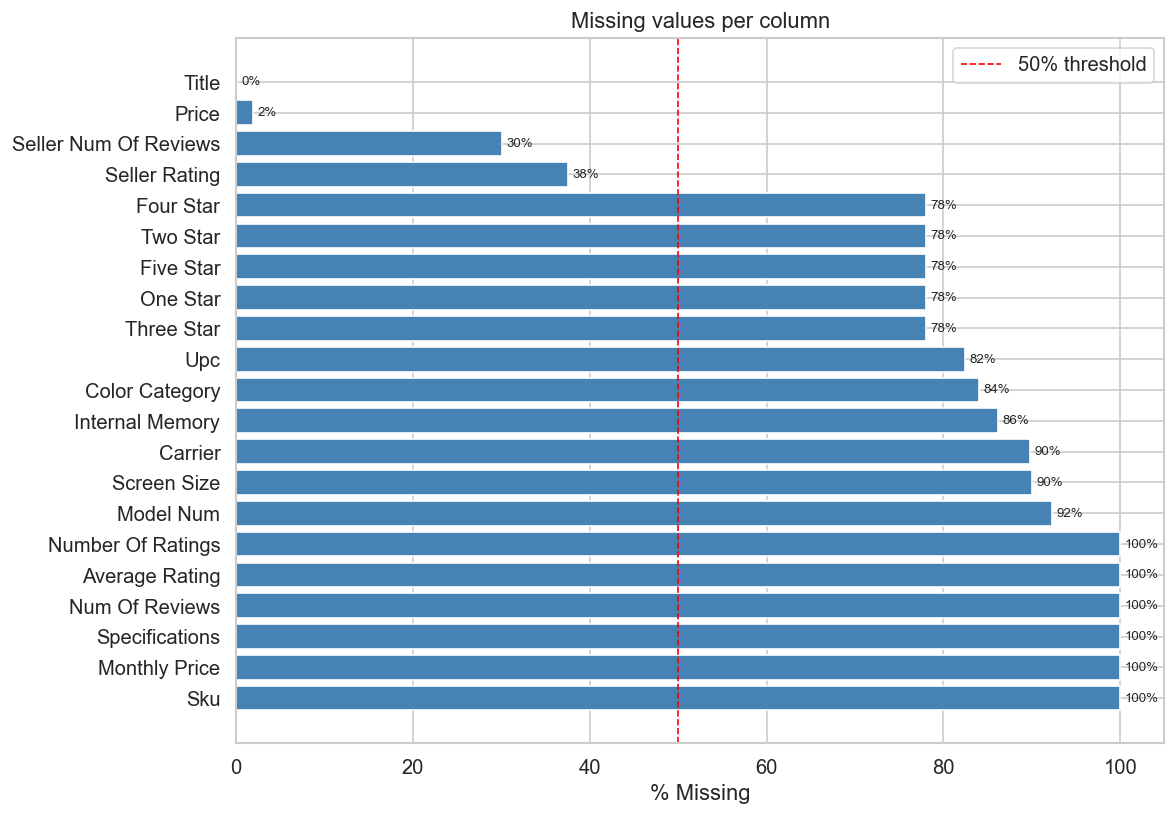

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
missing_plot = missing[missing['pct'] > 0]
bars = ax.barh(missing_plot.index, missing_plot['pct'], color='steelblue')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_xlabel('% Missing')
ax.set_title('Missing values per column')
ax.legend()
# annotate each bar with the percentage
for bar, pct in zip(bars, missing_plot['pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## 3. Price — the Target Variable

Everything the pricing agent does ultimately feeds into predicting `Price`. We need to understand its distribution before choosing a loss function and deciding whether to log-transform the target.

In [6]:
# Price is stored as '$369.08' — strip currency symbol and cast
df['price_usd'] = (
    df['Price']
    .str.replace(r'[\$,]', '', regex=True)
    .pipe(pd.to_numeric, errors='coerce')
)

print('Price summary:')
print(df['price_usd'].describe().apply(lambda x: f'${x:,.2f}'))
print(f"\nRows with valid price: {df['price_usd'].notna().sum():,} "
      f"({df['price_usd'].notna().mean()*100:.1f}%)")

Price summary:
count    $17,247.00
mean        $150.37
std         $416.32
min           $0.01
25%          $20.30
50%          $57.10
75%         $164.67
max      $35,900.00
Name: price_usd, dtype: str

Rows with valid price: 17,247 (98.1%)


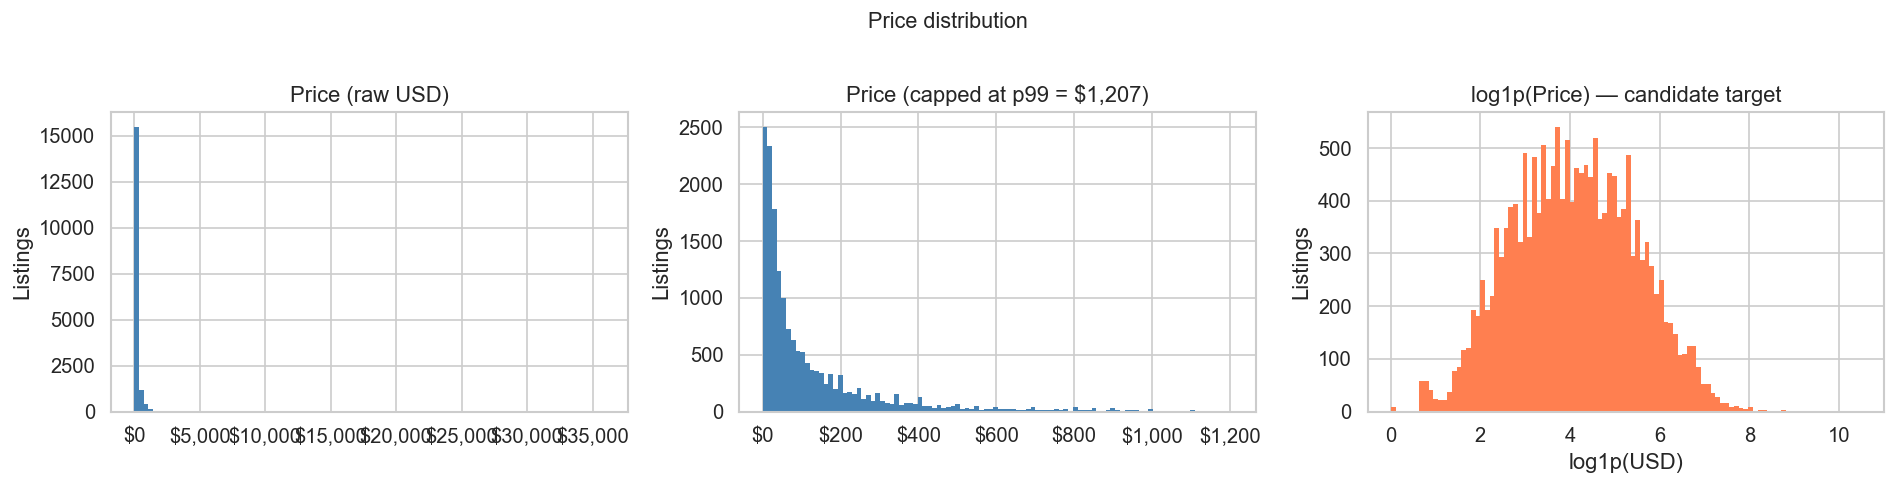

Skewness (raw):     45.18
Skewness (log1p):   0.05


In [7]:
prices = df['price_usd'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# raw distribution — likely right-skewed
axes[0].hist(prices, bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Price (raw USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# cap at 99th percentile to see the bulk of the distribution
p99 = prices.quantile(0.99)
axes[1].hist(prices[prices <= p99], bins=100, color='steelblue', edgecolor='none')
axes[1].set_title(f'Price (capped at p99 = ${p99:,.0f})')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# log-transformed — if this looks roughly normal, use log(price) as target
axes[2].hist(np.log1p(prices), bins=100, color='coral', edgecolor='none')
axes[2].set_title('log1p(Price) — candidate target')
axes[2].set_xlabel('log1p(USD)')

for ax in axes:
    ax.set_ylabel('Listings')

plt.suptitle('Price distribution', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f'Skewness (raw):     {prices.skew():.2f}')
print(f'Skewness (log1p):   {np.log1p(prices).skew():.2f}')

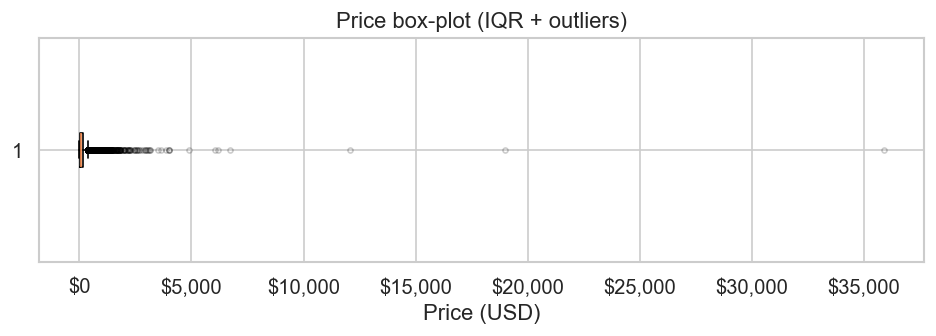

p1           $1.72
p5           $5.65
p25         $20.30
p50         $57.10
p75        $164.67
p95        $575.72
p99      $1,207.09
p100    $35,900.00
Name: price_usd, dtype: str

In [8]:
# box-plot to surface outlier magnitude
fig, ax = plt.subplots(figsize=(8, 3))
ax.boxplot(prices, vert=False, showfliers=True,
           flierprops=dict(marker='o', alpha=0.2, markersize=3))
ax.set_xlabel('Price (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Price box-plot (IQR + outliers)')
plt.tight_layout()
plt.show()

# quantile table — useful for choosing clipping bounds in the model pipeline
pd.Series(
    {f'p{q}': prices.quantile(q/100) for q in [1, 5, 25, 50, 75, 95, 99, 100]},
    name='price_usd'
).apply(lambda x: f'${x:,.2f}')

---
## 4. Seller Reputation

The eBay Browse API returns `sellerFeedbackPercentage` and `sellerFeedbackScore`. This section checks how much variance in price is explained by seller quality — if it's significant, `seller_rating` is a worthwhile feature.

In [9]:
# Seller Rating is stored as '98%', '100%', or a raw score — normalise to float
df['seller_rating_pct'] = (
    df['Seller Rating']
    .str.replace('%', '', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

print('Seller Rating (%) summary:')
print(df['seller_rating_pct'].describe())
print(f"\nCoverage: {df['seller_rating_pct'].notna().mean()*100:.1f}%")

Seller Rating (%) summary:
count    10988.000000
mean        98.964379
std          1.895357
min         33.300000
25%         98.500000
50%         99.500000
75%        100.000000
max        100.000000
Name: seller_rating_pct, dtype: float64

Coverage: 62.5%


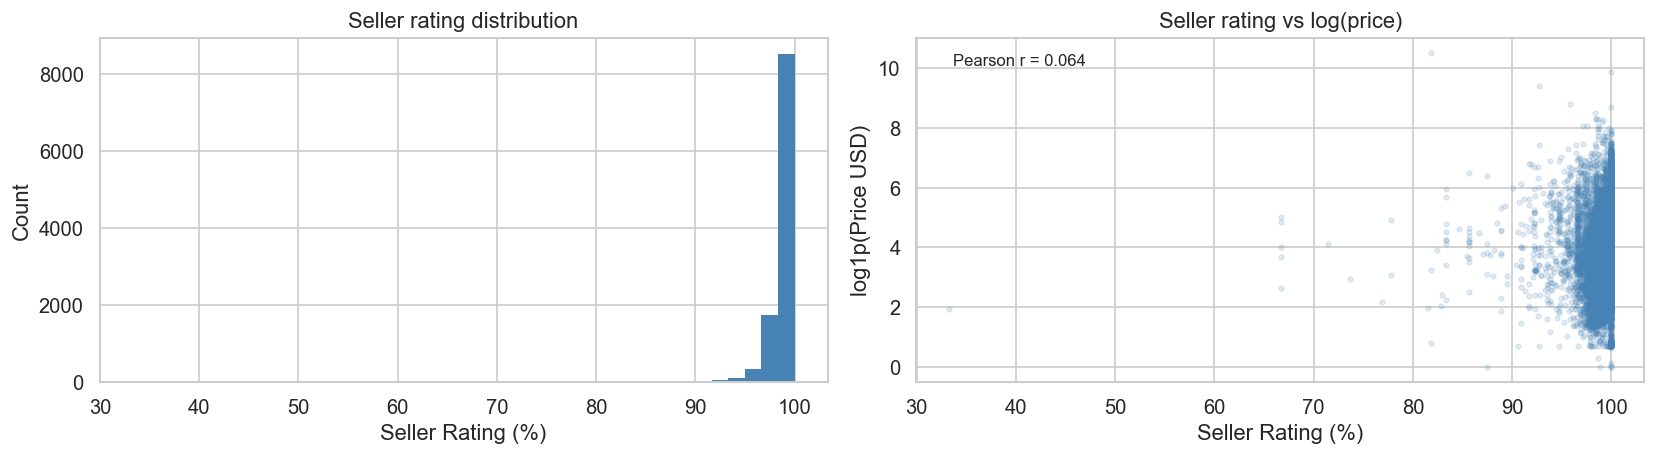

In [10]:
seller_df = df[['seller_rating_pct', 'price_usd']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# distribution of seller ratings
axes[0].hist(seller_df['seller_rating_pct'], bins=40, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Seller Rating (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Seller rating distribution')

# scatter: seller rating vs price (log scale for price)
axes[1].scatter(seller_df['seller_rating_pct'], np.log1p(seller_df['price_usd']),
                alpha=0.15, s=8, color='steelblue')
axes[1].set_xlabel('Seller Rating (%)')
axes[1].set_ylabel('log1p(Price USD)')
axes[1].set_title('Seller rating vs log(price)')

corr = seller_df['seller_rating_pct'].corr(np.log1p(seller_df['price_usd']))
axes[1].annotate(f'Pearson r = {corr:.3f}', xy=(0.05, 0.92),
                 xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# bucket ratings into bands and compare median prices
# helps decide whether to encode seller_rating as continuous or ordinal buckets
bins = [0, 80, 90, 95, 98, 100]
labels = ['<80%', '80–90%', '90–95%', '95–98%', '98–100%']
seller_df['rating_band'] = pd.cut(seller_df['seller_rating_pct'], bins=bins, labels=labels)

band_stats = (
    seller_df.groupby('rating_band', observed=True)['price_usd']
    .agg(['median', 'mean', 'count'])
    .round(2)
)
print(band_stats)

             median    mean  count
rating_band                       
<80%          38.81   57.31     11
80–90%        52.49  807.09     50
90–95%        65.48  203.16    204
95–98%        35.87  108.61   1346
98–100%       40.00  119.57   9243


---
## 5. Manufacturer / Brand

Brand is one of the strongest pricing signals for secondhand goods (Apple vs Samsung vs generic). The intake agent should try to extract brand from the title when a structured `Manufacturer` field is absent.

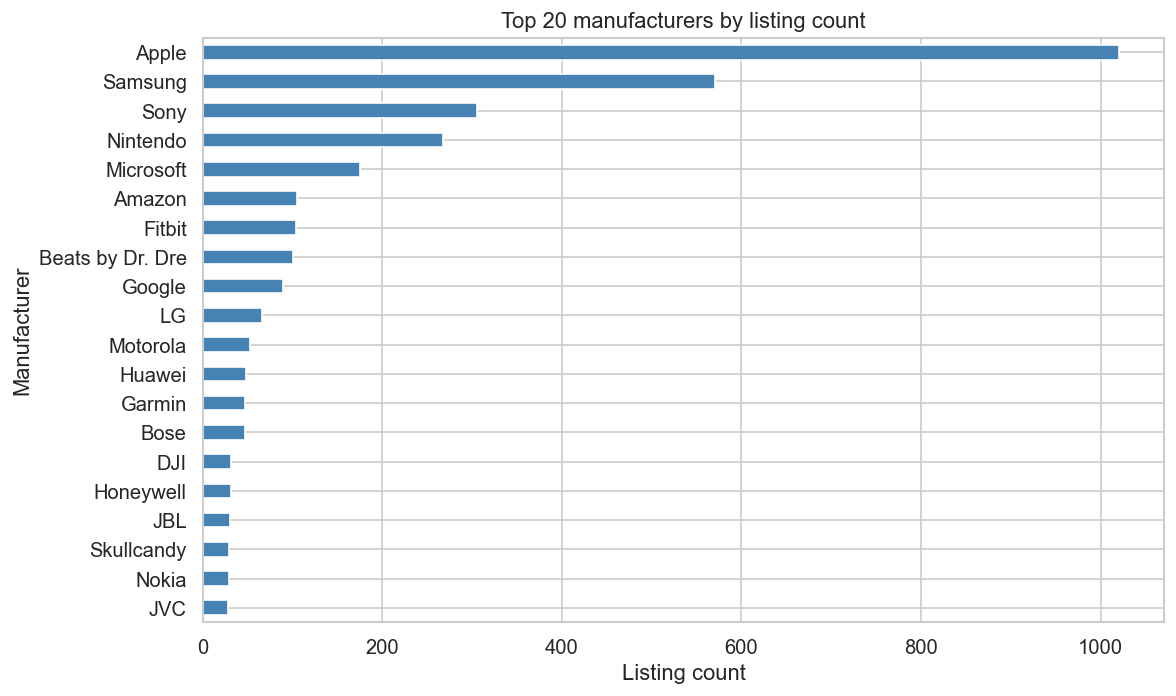

In [12]:
# top manufacturers by listing count
top_n = 20
top_manufacturers = df['Manufacturer'].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
top_manufacturers.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Listing count')
ax.set_title(f'Top {top_n} manufacturers by listing count')
plt.tight_layout()
plt.show()

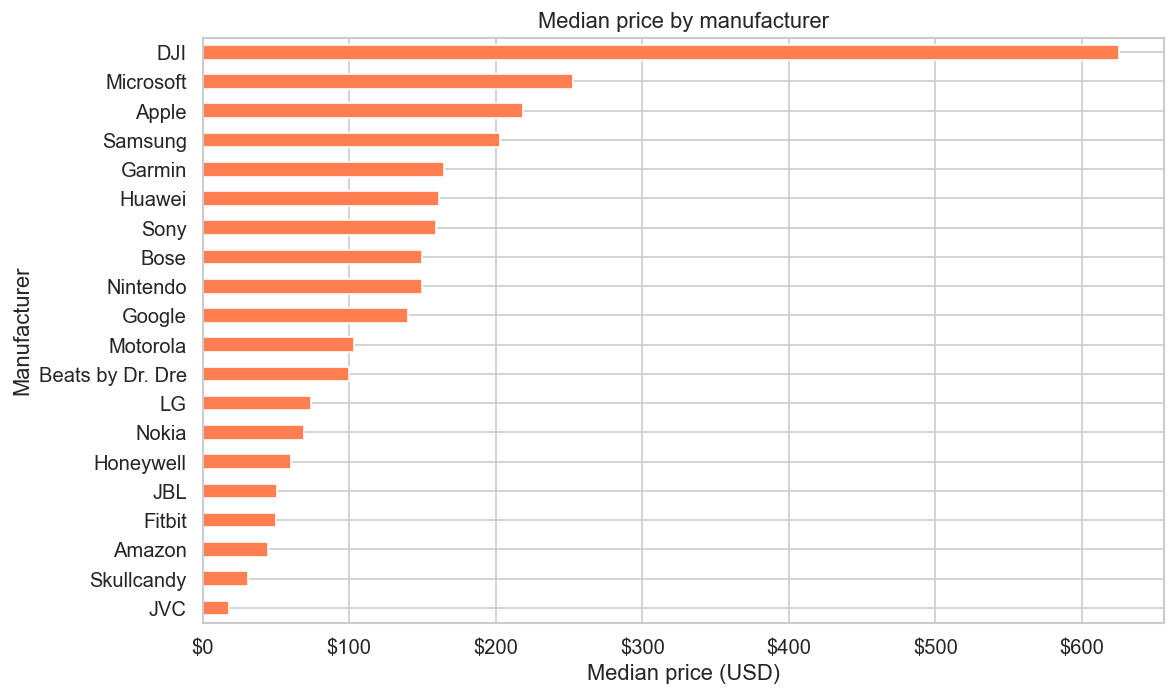

In [13]:
# median price by top manufacturer — key insight for the pricing model
top_mfr_names = top_manufacturers.index.tolist()
mfr_price = (
    df[df['Manufacturer'].isin(top_mfr_names)]
    .groupby('Manufacturer')['price_usd']
    .median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))
mfr_price.sort_values().plot.barh(ax=ax, color='coral')
ax.set_xlabel('Median price (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Median price by manufacturer')
plt.tight_layout()
plt.show()

---
## 6. Product Attributes

Structured attributes (storage, screen size, colour) are the kind of fields the NLP agent (Agent 5) will parse out of free-text descriptions. Here we check how complete and useful they are in the dataset.

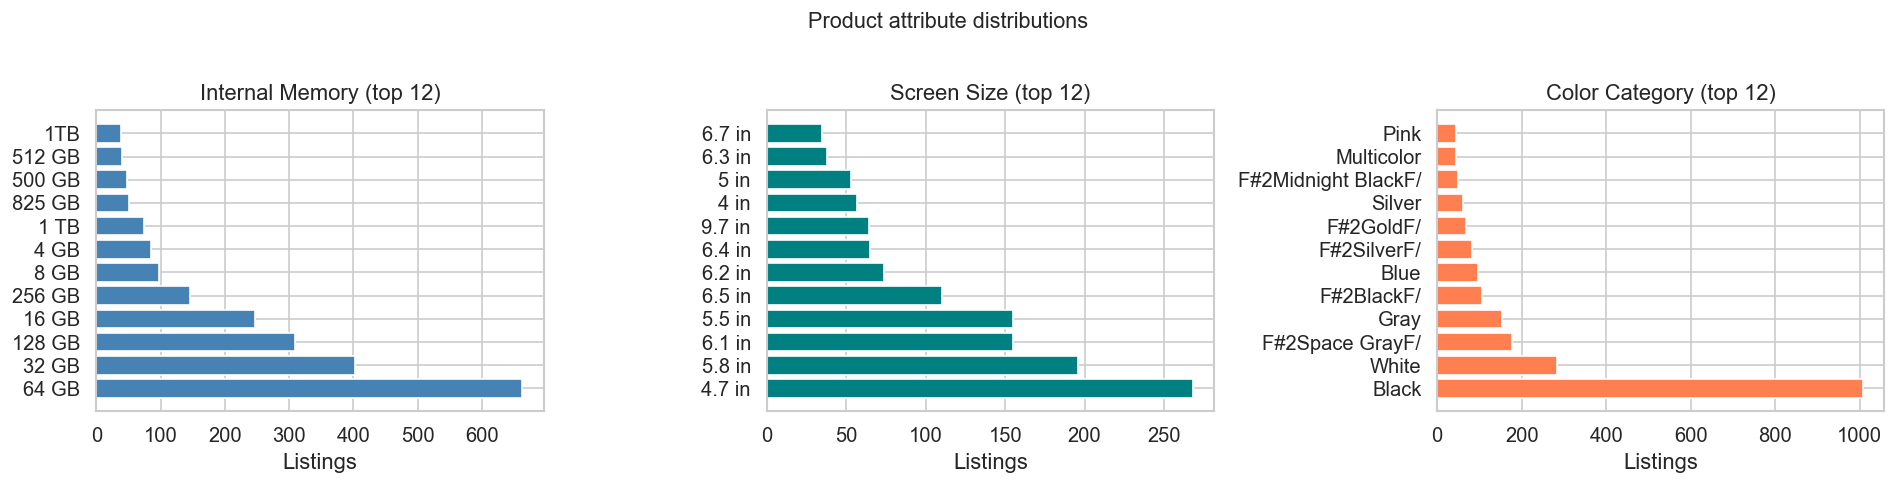

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Internal Memory — storage capacity has a strong effect on phone prices
mem_counts = df['Internal Memory'].value_counts().head(12)
axes[0].barh(mem_counts.index.astype(str), mem_counts.values, color='steelblue')
axes[0].set_title('Internal Memory (top 12)')
axes[0].set_xlabel('Listings')

# Screen Size
screen_counts = df['Screen Size'].value_counts().head(12)
axes[1].barh(screen_counts.index.astype(str), screen_counts.values, color='teal')
axes[1].set_title('Screen Size (top 12)')
axes[1].set_xlabel('Listings')

# Color Category
color_counts = df['Color Category'].value_counts().head(12)
axes[2].barh(color_counts.index.astype(str), color_counts.values, color='coral')
axes[2].set_title('Color Category (top 12)')
axes[2].set_xlabel('Listings')

plt.suptitle('Product attribute distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# median price by storage tier — quantifies the price uplift per tier
# the pricing model should capture this via an ordinal or numeric encoding
mem_price = (
    df.dropna(subset=['Internal Memory', 'price_usd'])
    .groupby('Internal Memory')['price_usd']
    .agg(['median', 'count'])
    .query('count >= 30')  # drop rare tiers with unreliable medians
    .sort_values('median', ascending=False)
)
print('Median price by storage tier (min 30 listings):')
print(mem_price.to_string())

Median price by storage tier (min 30 listings):
                 median  count
Internal Memory               
825 GB           850.00     50
1 TB             630.00     74
256 GB           484.22    140
512 GB           431.63     39
128 GB           309.99    303
1TB              256.91     37
64 GB            236.73    646
500 GB           207.73     45
32 GB            149.97    390
4 GB             129.99     85
8 GB              68.26     97
16 GB             65.00    239


---
## 7. Title Analysis

When structured fields are missing (as they often are from seller-entered listings), the pricing agent must fall back on the item **title**. This section characterises title length and vocabulary to inform the NLP feature engineering step.

In [16]:
# basic text features on the title column
df['title_len_chars'] = df['Title'].str.len()
df['title_len_words'] = df['Title'].str.split().str.len()

print('Title length (characters):')
print(df['title_len_chars'].describe().round(1))
print()
print('Title length (words):')
print(df['title_len_words'].describe().round(1))

Title length (characters):
count    17565.0
mean        66.9
std         18.5
min          1.0
25%         58.0
50%         72.0
75%         79.0
max        174.0
Name: title_len_chars, dtype: float64

Title length (words):
count    17565.0
mean        10.9
std          3.3
min          1.0
25%          9.0
50%         11.0
75%         13.0
max         27.0
Name: title_len_words, dtype: float64


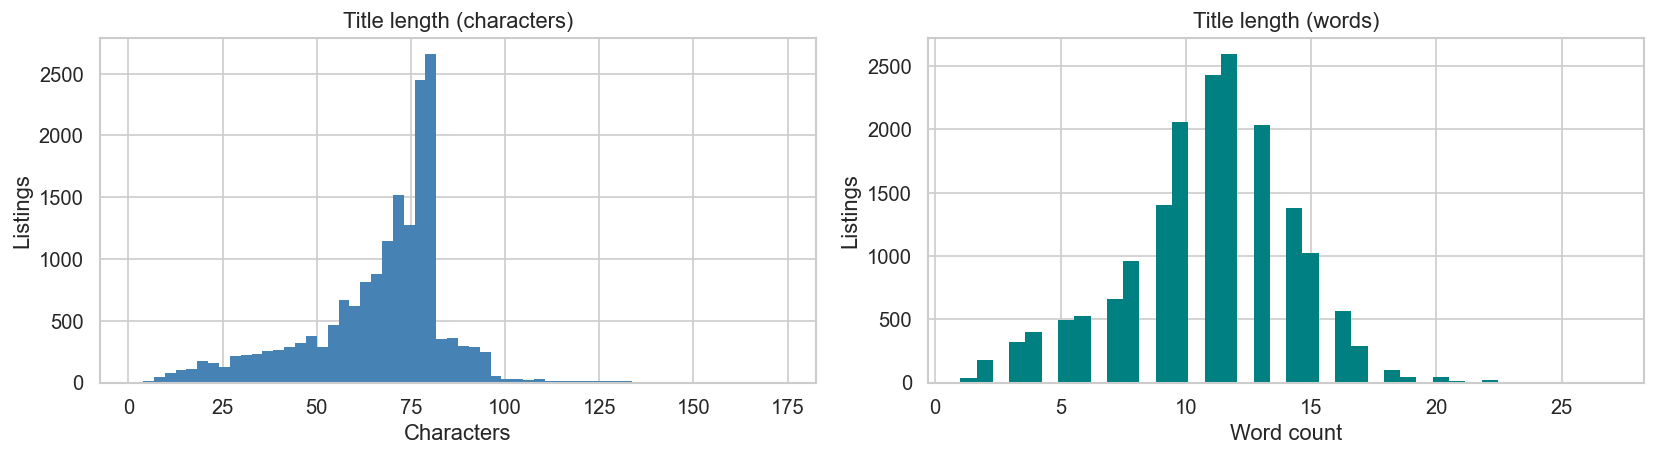

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['title_len_chars'].dropna(), bins=60, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Listings')
axes[0].set_title('Title length (characters)')

axes[1].hist(df['title_len_words'].dropna(), bins=40, color='teal', edgecolor='none')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Listings')
axes[1].set_title('Title length (words)')

plt.tight_layout()
plt.show()

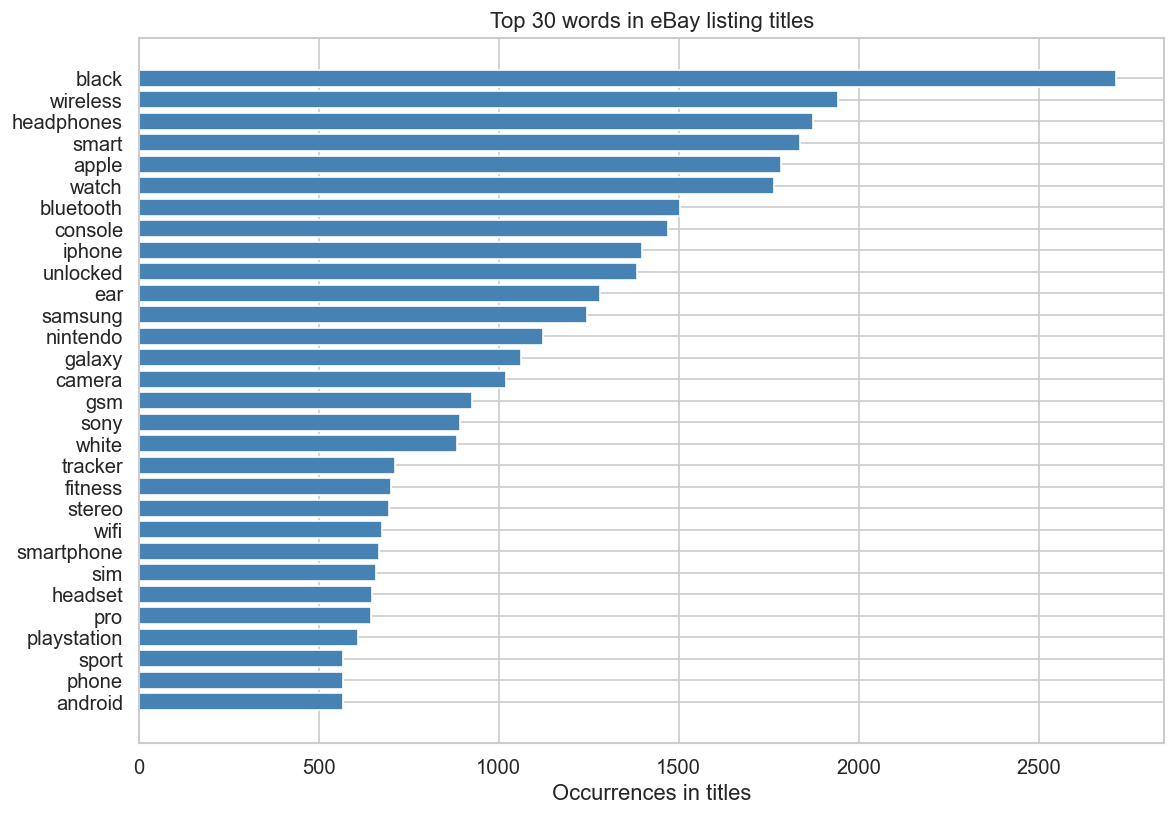

In [18]:
from collections import Counter
import re

# top unigrams in titles — shows dominant product categories in this dataset
STOPWORDS = {
    'the', 'for', 'and', 'with', 'in', 'a', 'of', 'to', 'new',
    'used', 'sale', 'online', '-', '–', '|', '/', '&', 'set'
}

all_words = [
    w.lower() for title in df['Title'].dropna()
    for w in re.findall(r'[a-zA-Z]{3,}', title)
    if w.lower() not in STOPWORDS
]

top_words = Counter(all_words).most_common(30)
words_df = pd.DataFrame(top_words, columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(words_df['word'][::-1], words_df['count'][::-1], color='steelblue')
ax.set_xlabel('Occurrences in titles')
ax.set_title('Top 30 words in eBay listing titles')
plt.tight_layout()
plt.show()

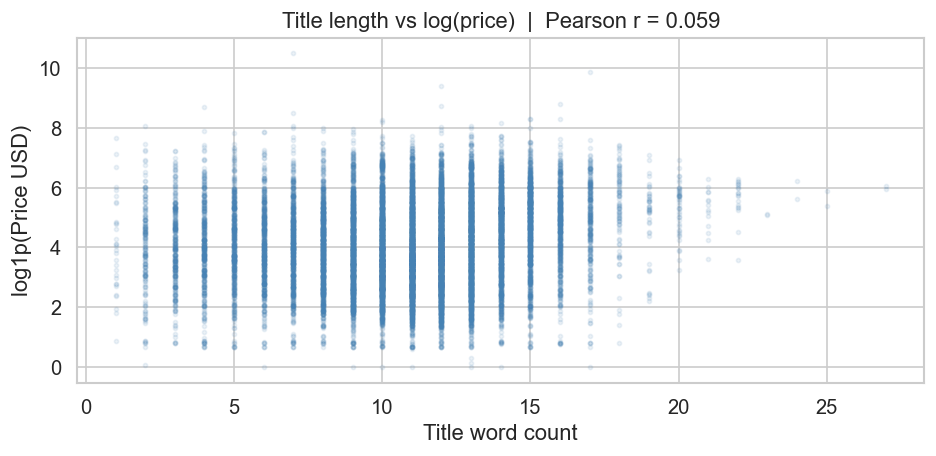

In [19]:
# does a longer, more descriptive title correlate with higher price?
# agents writing titles could use this insight
corr_words_price = df[['title_len_words', 'price_usd']].dropna().corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(df['title_len_words'], np.log1p(df['price_usd']),
           alpha=0.1, s=6, color='steelblue')
ax.set_xlabel('Title word count')
ax.set_ylabel('log1p(Price USD)')
ax.set_title(f'Title length vs log(price)  |  Pearson r = {corr_words_price:.3f}')
plt.tight_layout()
plt.show()

---
## 8. Ratings & Review Volume

Review counts and star distributions are **demand signals** — popular items tend to sell at stable prices. The pricing model may use review volume as a proxy for liquidity (how quickly an item is likely to sell at a given price).

In [20]:
# cast numeric rating columns
for col in ['Average Rating', 'Number Of Ratings', 'Num Of Reviews',
            'Five Star', 'Four Star', 'Three Star', 'Two Star', 'One Star']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print('Average Rating coverage:', f"{df['Average Rating'].notna().mean()*100:.1f}%")
print('Number of Ratings coverage:', f"{df['Number Of Ratings'].notna().mean()*100:.1f}%")

Average Rating coverage: 0.0%
Number of Ratings coverage: 0.0%


In [21]:
rated = df[df['Average Rating'].notna() & df['price_usd'].notna()]

if len(rated) > 10:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(rated['Average Rating'], bins=20, color='steelblue', edgecolor='none')
    axes[0].set_xlabel('Average Rating')
    axes[0].set_ylabel('Listings')
    axes[0].set_title('Average Rating distribution')

    axes[1].scatter(rated['Average Rating'], np.log1p(rated['price_usd']),
                    alpha=0.3, s=10, color='coral')
    r = rated['Average Rating'].corr(np.log1p(rated['price_usd']))
    axes[1].set_xlabel('Average Rating')
    axes[1].set_ylabel('log1p(Price USD)')
    axes[1].set_title(f'Rating vs log(price)  |  r = {r:.3f}')

    plt.tight_layout()
    plt.show()
else:
    print(f'Only {len(rated)} rows have both rating and price — skipping scatter.')

Only 0 rows have both rating and price — skipping scatter.


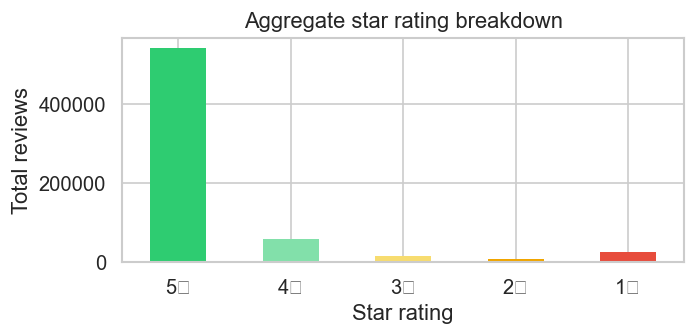

In [22]:
# star breakdown — useful for building a weighted sentiment score feature
star_cols = ['Five Star', 'Four Star', 'Three Star', 'Two Star', 'One Star']
star_totals = df[star_cols].sum().rename(index={
    'Five Star': '5★', 'Four Star': '4★', 'Three Star': '3★',
    'Two Star': '2★', 'One Star': '1★'
})

fig, ax = plt.subplots(figsize=(6, 3))
colors = ['#2ecc71', '#82e0aa', '#f7dc6f', '#f0a500', '#e74c3c']
star_totals.plot.bar(ax=ax, color=colors, edgecolor='none')
ax.set_xlabel('Star rating')
ax.set_ylabel('Total reviews')
ax.set_title('Aggregate star rating breakdown')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

---
## 9. Stock / Availability

The `Stock` field indicates whether the item was in-stock at crawl time. For the pricing agent, low-stock or single-unit items may command a premium.

Stock
True     16803
False      774
Name: count, dtype: int64


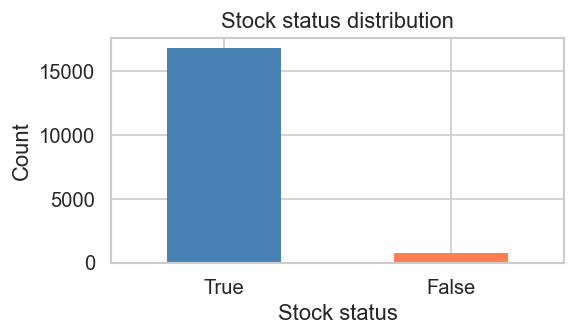

In [23]:
stock_counts = df['Stock'].value_counts(dropna=False)
print(stock_counts)

fig, ax = plt.subplots(figsize=(5, 3))
stock_counts.plot.bar(ax=ax, color=['steelblue', 'coral', 'grey'], edgecolor='none')
ax.set_xlabel('Stock status')
ax.set_ylabel('Count')
ax.set_title('Stock status distribution')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [24]:
# median price by stock status — does availability affect price in this dataset?
stock_price = (
    df.dropna(subset=['price_usd'])
    .groupby('Stock')['price_usd']
    .agg(['median', 'mean', 'count'])
    .round(2)
)
print(stock_price)

       median    mean  count
Stock                       
False   46.13  129.38    590
True    58.28  151.11  16657


---
## 10. Feature Correlation Matrix

Consolidated view of all numeric feature correlations with `price_usd` — this is the shortlist from which the XGBoost feature set should be selected.

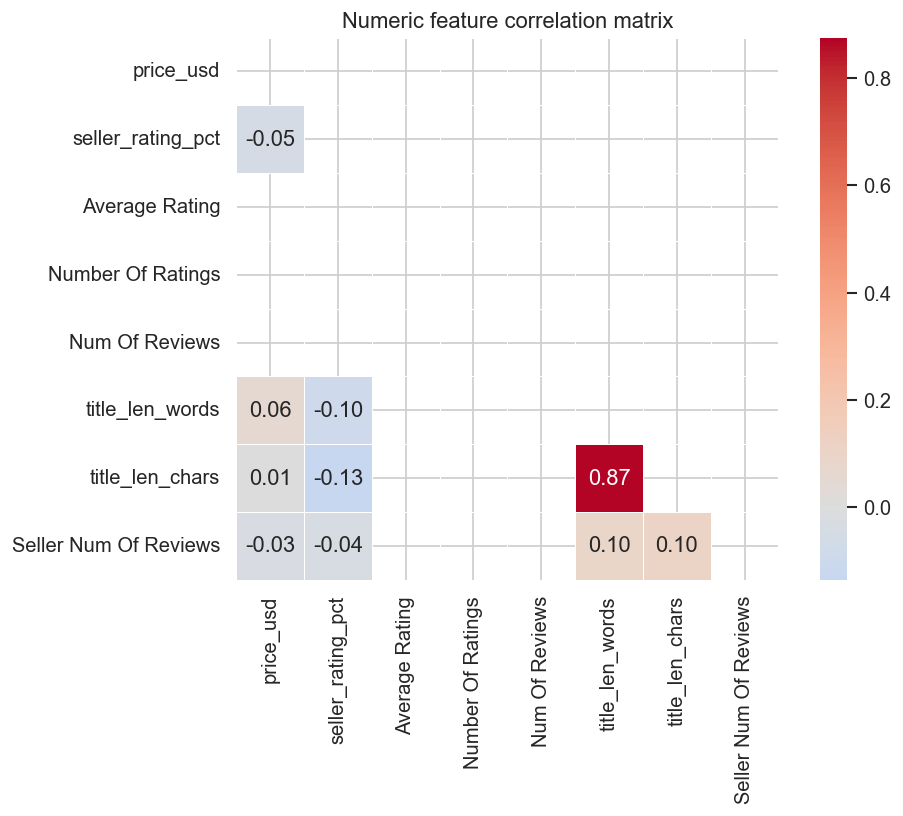

In [25]:
numeric_cols = [
    'price_usd',
    'seller_rating_pct',
    'Average Rating',
    'Number Of Ratings',
    'Num Of Reviews',
    'title_len_words',
    'title_len_chars',
    'Seller Num Of Reviews',
]

df['Seller Num Of Reviews'] = pd.to_numeric(df['Seller Num Of Reviews'], errors='coerce')

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, square=True
)
ax.set_title('Numeric feature correlation matrix')
plt.tight_layout()
plt.show()

In [26]:
# rank features by absolute correlation with price
price_corr = (
    corr_matrix['price_usd']
    .drop('price_usd')
    .abs()
    .sort_values(ascending=False)
    .rename('|corr with price|')
)
print(price_corr.to_string())

title_len_words          0.058728
seller_rating_pct        0.049301
Seller Num Of Reviews    0.031925
title_len_chars          0.006648
Average Rating                NaN
Number Of Ratings             NaN
Num Of Reviews                NaN


---
## 11. Summary & Implications for Agent 2

| Finding | Implication |
|---------|-------------|
| Price is heavily right-skewed | Use **log1p(price)** as the XGBoost regression target; exponentiate predictions before returning `suggested_price` |
| Manufacturer is a strong price signal | Always attempt brand extraction from title; encode as a high-cardinality categorical (target encoding or leave-one-out) |
| Storage tier drives clear price steps | Parse `Internal Memory` from specs/title; encode as numeric GB value |
| Seller rating has low-to-moderate correlation | Include `seller_rating_pct` as a feature but do not over-weight it; most sellers cluster at 95–100% |
| Reviews / ratings are sparse (>90% null) | Do **not** depend on `Average Rating` as a required feature; treat as optional enrichment |
| Title length has near-zero price correlation | Title length alone is not a useful feature; use NLP embeddings instead |
| Most listings are in-stock | `Stock` field adds little signal in training data; may still be useful at inference time |

### Recommended feature set for MVP XGBoost model

```
Required  : manufacturer (encoded), internal_memory_gb (numeric), title_embedding (vector)
Optional  : seller_rating_pct, color_category, screen_size_in, num_ratings
Target    : log1p(price_usd)
```

### Data quality gap vs live eBay API

This dataset is heavily skewed toward **electronics (phones, headphones)**. The live system must handle a much broader category mix — the feature engineering pipeline should be category-aware and not hard-code assumptions derived solely from this dataset.